### Adjacency Matrix

In [44]:
# A mapping from node names to indices for clarity
node_map_matrix = {'A': 0, 'B': 1, 'C': 2, 'D': 3, 'E': 4, 'F': 5}
INF = float('inf')

# Adjacency matrix for the graph
adj_matrix = [
    # A,    B,    C,    D,    E,    F
    [0,    2,    4,    INF,  INF,  INF],  # Node A
    [INF,  0,    1,    7,    INF,  INF],  # Node B
    [INF,  INF,  0,    INF,  3,    INF],  # Node C
    [INF,  INF,  INF,  0,    INF,  1],    # Node D
    [INF,  INF,  INF,  2,    0,    5],    # Node E
    [INF,  INF,  INF,  INF,  INF,  0]     # Node F
]

In [45]:
def dijkstra_mat(graph, start_value):
    V = len(graph)
    # 1. Initialization (Assuming start_value is the index of the start node)
    dist = [INF for i in range(V)]
    pi = [None for i in range(V)]
    finished = set()
    
    dist[start_value] = 0 # Distance from source to itself is 0

    while (len(finished) < V):
        min_dist = INF
        u = -1 
        
        for i in range(V):
            if i not in finished and dist[i] < min_dist:
                min_dist = dist[i]
                u = i

        if u == -1:
            break
            
        finished.add(u)

        for v in range(V):
            weight = graph[u][v]
            if weight > 0 and v not in finished:
                if dist[u] + weight < dist[v]:
                    dist[v] = dist[u] + weight
                    pi[v] = u 

    return dist, pi


start_node_index = 0 # Start at A

distances, predecessors = dijkstra_mat(adj_matrix, start_node_index)

# print(distances) # Output: [0, 8, 9, 5, 7]
# print(predecessors) # Output: [None, 3, 1, 0, 3]

In [46]:
print(distances) # Output: [0, 8, 9, 5, 7]
print(predecessors) # Output: [None, 3, 1, 0, 3] 

[0, 2, 3, 8, 6, 9]
[None, 0, 1, 4, 2, 3]


### Adjacency List

In [47]:
# A mapping from node names to indices for clarity
node_map_list = {'A': 0, 'B': 1, 'C': 2, 'D': 3, 'E': 4, 'F': 5}

# Mapping: 0:A, 1:B, 2:C, 3:D, 4:E, 5:F

# Adjacency list representation using a dictionary with integer keys
adj_dict_int = {
    0: [(1, 2), (2, 4)],
    1: [(2, 1), (3, 7)],
    2: [(4, 3)],
    3: [(5, 1)],
    4: [(3, 2), (5, 5)],
    5: []
}

In [48]:
import heapq
min_heap = [0,1,2,3,4,5]
heapq.heapify(min_heap)
min_heap

[0, 1, 2, 3, 4, 5]

In [49]:
def dijkstra_list(adj_list, start):
    V = len(adj_list.keys())
    dist = [INF for i  in range(V)]
    pi = [None for i  in range(V)]
    visit = set()

    dist[start] = 0
    while len(visit) < len(adj_list):
        min_dist = INF
        u = -1
        for i in range(V):
            if i not in visit and dist[i] < min_dist:
                min_dist = dist[i]
                u = i
        if u == -1:
            break

        visit.add(u)
        for vert, weight in adj_list[u]:
            if dist[u] + weight < dist[vert]:
                dist[vert] = dist[u] + weight
                pi[vert] = u
    return dist, pi


INF = float('inf')

class Heap():

    def __init__(self):
        self.array = []
        self.size = 0
        self.pos = []

    def newMinHeapNode(self, v, dist):
        minHeapNode = [v, dist]
        return minHeapNode

    def swapMinHeapNode(self, a, b):
        t = self.array[a]
        self.array[a] = self.array[b]
        self.array[b] = t

    def minHeapify(self, idx):
        smallest = idx
        left = 2*idx + 1
        right = 2*idx + 2

        if (left < self.size and
           self.array[left][1]
            < self.array[smallest][1]):
            smallest = left

        if (right < self.size and
           self.array[right][1]
            < self.array[smallest][1]):
            smallest = right

        # The nodes to be swapped in min
        # heap if idx is not smallest
        if smallest != idx:

            # Swap positions
            self.pos[self.array[smallest][0]] = idx
            self.pos[self.array[idx][0]] = smallest

            # Swap nodes
            self.swapMinHeapNode(smallest, idx)

            self.minHeapify(smallest)

    # Standard function to extract minimum
    # node from heap
    def extractMin(self):

        # Return NULL wif heap is empty
        if self.isEmpty():
            return

        # Store the root node
        root = self.array[0]

        # Replace root node with last node
        lastNode = self.array[self.size - 1]
        self.array[0] = lastNode

        # Update position of last node
        self.pos[lastNode[0]] = 0
        self.pos[root[0]] = self.size - 1

        # Reduce heap size and heapify root
        self.size -= 1
        self.minHeapify(0)

        return root

    def isEmpty(self):
        return True if self.size == 0 else False

    def decreaseKey(self, v, dist):

        # Get the index of v in  heap array

        i = self.pos[v]

        # Get the node and update its dist value
        self.array[i][1] = dist

        # Travel up while the complete tree is
        # not heapified. This is a O(Logn) loop
        while (i > 0 and self.array[i][1] <
                  self.array[(i - 1) // 2][1]):

            # Swap this node with its parent
            self.pos[ self.array[i][0] ] = (i-1)//2
            self.pos[ self.array[(i-1)//2][0] ] = i
            self.swapMinHeapNode(i, (i - 1)//2 )

            # move to parent index
            i = (i - 1) // 2

    # A utility function to check if a given 
    # vertex 'v' is in min heap or not
    def isInMinHeap(self, v):

        if self.pos[v] < self.size:
            return True
        return False


def printArr(dist, n):
    print ("Vertex\tDistance from source")
    for i in range(n):
        print ("%d\t\t%d" % (i,dist[i]))

def dijkstra_heap(adj_list, src):

        V = len(adj_list.keys())
        dist = []   # dist values used to pick minimum 
                    # weight edge in cut

        # minHeap represents set E
        minHeap = Heap()

        #  Initialize min heap with all vertices. 
        # dist value of all vertices
        for v in range(V):
            dist.append(INF)
            minHeap.array.append(minHeap.newMinHeapNode(v, dist[v]))
            minHeap.pos.append(v)

        minHeap.pos[src] = src
        dist[src] = 0
        minHeap.decreaseKey(src, dist[src])

        # Initially size of min heap is equal to V
        minHeap.size = V
        while not minHeap.isEmpty():
            newHeapNode = minHeap.extractMin()
            u = newHeapNode[0]
            for vert, weight in adj_list[u]:
                if (minHeap.isInMinHeap(vert) and weight + dist[u] < dist[vert]):
                        dist[vert] = weight + dist[u]
                        minHeap.decreaseKey(vert, dist[vert])

        # printArr(dist,V)

In [50]:
dijkstra_list(adj_dict_int, 0)

([0, 2, 3, 8, 6, 9], [None, 0, 1, 4, 2, 3])

In [51]:
print(dijkstra_mat(adj_matrix, start_node_index))
print(dijkstra_list(adj_dict_int, 0))
print(dijkstra_heap(adj_dict_int, 0))

([0, 2, 3, 8, 6, 9], [None, 0, 1, 4, 2, 3])
([0, 2, 3, 8, 6, 9], [None, 0, 1, 4, 2, 3])
None


### Ideal ans

In [52]:
# The shortest distance from 'A' to every other node
ideal_distances = {
    'A': 0,
    'B': 2,
    'C': 3,   # via A -> B -> C
    'D': 8,   # via A -> B -> C -> E -> D
    'E': 6,   # via A -> B -> C -> E
    'F': 9    # via A -> B -> C -> E -> D -> F
}
# The predecessors to reconstruct the shortest paths
ideal_previous_nodes = {
    'B': 'A',
    'C': 'B',
    'E': 'C',
    'D': 'E',
    'F': 'D'
}

### Benchmark testing

Matrix times: [0.0, 0.0200192928314209, 0.0835564136505127, 0.3681511878967285]
List times: [0.0, 0.009764671325683594, 0.04038286209106445, 0.10528159141540527]


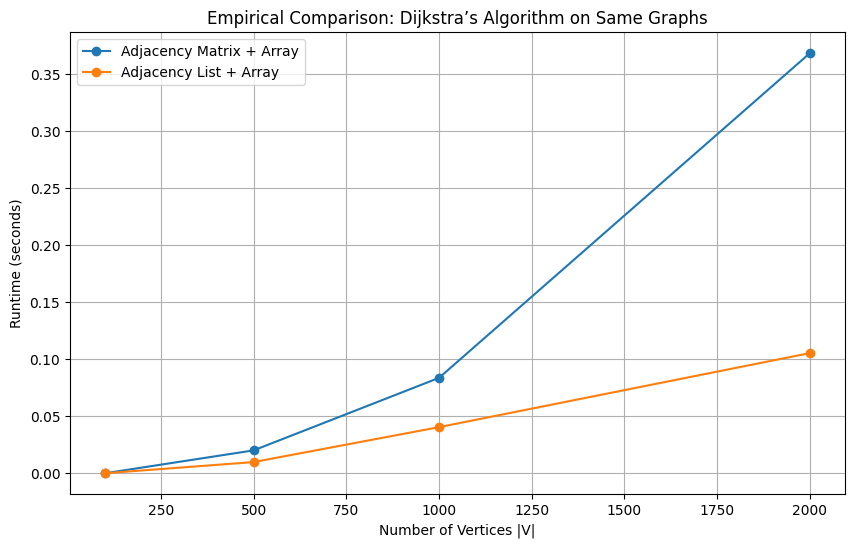

In [ ]:
import numpy as np
import time
import matplotlib.pyplot as plt

INF = 999999

# --- Graph generation ---
def generate_graph_matrix(V, max_weight=10, density=0.8): # Mod density
    graph = np.random.randint(0, max_weight + 1, size=(V, V))
    mask = np.random.rand(V, V) < density  # randomly remove some edges
    graph = graph * mask
    np.fill_diagonal(graph, 0)
    return graph.tolist()

# --- Conversion ---
def matrix_to_adj_list(matrix):
    V = len(matrix)
    adj_list = {i: [] for i in range(V)}
    for i in range(V):
        for j in range(V):
            w = matrix[i][j]
            if w != 0:
                adj_list[i].append((j, w))
    return adj_list


# --- Measure empirical runtime ---
sizes = [100, 500, 1000, 2000]
times_matrix = []
times_list = []

for V in sizes:
    graph = generate_graph_matrix(V, density=0.3)
    adj_list = matrix_to_adj_list(graph)
    
    # Matrix version
    start_time = time.time()
    dijkstra_mat(graph, 0)
    times_matrix.append(time.time() - start_time)

    # List version
    start_time = time.time()
    dijkstra_heap(adj_list, 0)
    times_list.append(time.time() - start_time)

print("Matrix times:", times_matrix)
print("List times:", times_list)

# --- Plot comparison ---
plt.figure(figsize=(10,6))
plt.plot(sizes, times_matrix, marker='o', label="Adjacency Matrix + Array")
plt.plot(sizes, times_list, marker='o', label="Adjacency List + Array")
plt.xlabel("Number of Vertices |V|")
plt.ylabel("Runtime (seconds)")
plt.title("Empirical Comparison: Dijkstra’s Algorithm on Same Graphs")
plt.legend()
plt.grid(True)
plt.show()


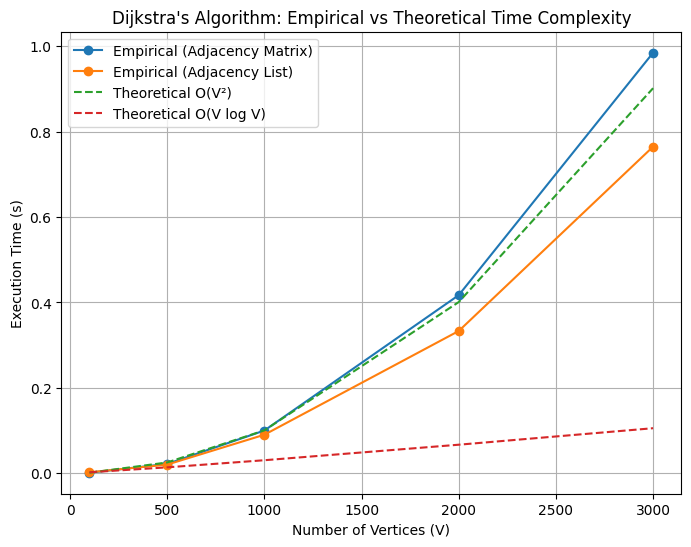

In [54]:
import time
import matplotlib.pyplot as plt

# -----------------
# Graph Generation
# -----------------
def generate_graph_matrix(V, max_weight=10):
    graph = np.random.randint(0, max_weight + 1, size=(V, V))
    np.fill_diagonal(graph, 0)
    return graph.tolist()

def matrix_to_adj_list(matrix):
    adj_list = {i: [] for i in range(len(matrix))}
    for i in range(len(matrix)):
        for j in range(len(matrix)):
            if matrix[i][j] != 0:  # ignore zero weights (no self-loops)
                adj_list[i].append((j, matrix[i][j]))
    return adj_list

# -----------------
# Benchmark
# -----------------
sizes = [100, 500, 1000, 2000, 3000]
times_matrix = []
times_list = []

for V in sizes:
    graph = generate_graph_matrix(V)
    adj_list = matrix_to_adj_list(graph)

    # Matrix-based Dijkstra
    start_time = time.time()
    dijkstra_mat(graph, 0)
    times_matrix.append(time.time() - start_time)

    # List-based Dijkstra
    start_time = time.time()
    dijkstra_heap(adj_list, 0)
    times_list.append(time.time() - start_time)

# -----------------
# Theoretical Curves
# -----------------
# Scale factors to align with real timings (just for visualization)
scale_matrix = times_matrix[0] / (sizes[0]**2)
scale_list = times_list[0] / (sizes[0] * np.log(sizes[0]))

theoretical_matrix = [scale_matrix * (v**2) for v in sizes]
theoretical_list = [scale_list * (v * np.log(v)) for v in sizes]

# -----------------
# Plot Results
# -----------------
plt.figure(figsize=(8,6))
plt.plot(sizes, times_matrix, 'o-', label="Empirical (Adjacency Matrix)")
plt.plot(sizes, times_list, 'o-', label="Empirical (Adjacency List)")
plt.plot(sizes, theoretical_matrix, '--', label="Theoretical O(V²)")
plt.plot(sizes, theoretical_list, '--', label="Theoretical O(V log V)")
plt.xlabel("Number of Vertices (V)")
plt.ylabel("Execution Time (s)")
plt.title("Dijkstra's Algorithm: Empirical vs Theoretical Time Complexity")
plt.legend()
plt.grid(True)
plt.show()
